# Classification d’images (Cats vs Dogs) avec LBP + SVM

## Objectif
Utiliser LBP (Local Binary Pattern) pour extraire les caractéristiques
puis SVM pour classifier les images.

Pipeline :
Images → LBP → Features → SVM → Prédiction

## Etape 1 : Importation

In [50]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import local_binary_pattern
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

## Etape 2 : Chargement des images

In [51]:
def load_images(path, label):
    images = []
    labels = []
    
    for img_name in os.listdir(path):
        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path)
        
        if img is None:
            continue
        
        img = cv2.resize(img, (128, 128))
        images.append(img)
        labels.append(label)
    
    return images, labels

cats, cats_labels = load_images("C:/Users/4B/image_project/dataset/cats", 0)
dogs, dogs_labels = load_images("C:/Users/4B/image_project/dataset/dogs", 1)

X = cats + dogs
y = cats_labels + dogs_labels

print("Nombre d’images :", len(X))

Nombre d’images : 482


## afffichage de l'image 

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

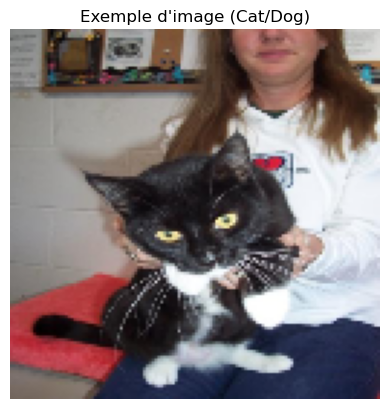

In [52]:
# afficher la première image
plt.imshow(cv2.cvtColor(X[0], cv2.COLOR_BGR2RGB))
plt.title("Exemple d'image (Cat/Dog)")
plt.axis('off')

## nombres des images 

In [53]:
print("Nombre total d’images :", len(X))
print("Nombre de chats :", len(cats))
print("Nombre de chiens :", len(dogs))

Nombre total d’images : 482
Nombre de chats : 241
Nombre de chiens : 241


## Etape 22 : Extraction LBP

In [54]:
lbp_features = []

radius = 1
n_points = 8 * radius

for img in X:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    lbp = local_binary_pattern(gray, n_points, radius, method='uniform')
    
    # Histogramme
    hist, _ = np.histogram(lbp.ravel(),
                           bins=np.arange(0, n_points + 3),
                           range=(0, n_points + 2))
    
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)
    
    lbp_features.append(hist)

print("Feature size:", len(lbp_features[0]))

Feature size: 10


## Partie 4 : Préparation des données

In [55]:
X_data = np.array(lbp_features)
y_data = np.array(y)

print(X_data.shape)

(482, 10)


## Etape 5 : Normalisation

In [56]:
scaler = StandardScaler()
X_data = scaler.fit_transform(X_data)

## Etape 6 : Division des données

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, random_state=42
)
print("Train:", len(X_train))
print("Test:", len(X_test))

Train: 385
Test: 97


## Etape 7 : : Entraînement du modèle SVM

In [58]:
model = SVC(kernel='rbf')
model.fit(X_train, y_train)
print("Modèle entraîné ✔️")

Modèle entraîné ✔️


## Etape 8 : Prédiction

In [59]:
y_pred = model.predict(X_test)

## Etape 9  : Évaluation

In [60]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5979381443298969
              precision    recall  f1-score   support

           0       0.62      0.58      0.60        50
           1       0.58      0.62      0.60        47

    accuracy                           0.60        97
   macro avg       0.60      0.60      0.60        97
weighted avg       0.60      0.60      0.60        97



## Conclusion

LBP permet de capturer la texture des images.
Les performances seront comparées avec HOG pour déterminer le meilleur algorithme.